In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Titanic.csv',usecols=['Age',"Fare",'Survived'])
df.sample(5)

,Survived,Age,Fare
119,0,2.0,31.2750
689,1,15.0,211.3375
209,1,40.0,31.0000
466,0,NaN,0.0000
526,1,50.0,10.5000


In [3]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [4]:
X=df.drop(columns=['Survived'])
X

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
886,27.0,13.0000
887,19.0,30.0000
888,NaN,23.4500
889,26.0,30.0000


In [5]:
y=df['Survived']
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
X_train.sample(5)

,Age,Fare
265,36.0,10.5000
654,18.0,6.7500
561,40.0,7.8958
88,23.0,263.0000
826,NaN,56.4958


In [8]:
X_test.sample(5)

,Age,Fare
462,47.0,38.5000
400,39.0,7.9250
340,2.0,26.0000
152,55.5,8.0500
643,NaN,56.4958


In [23]:
age_mean=X_train['Age'].mean()
age_median=X_train['Age'].median()

In [25]:
X_train['Age_mean']=X_train['Age'].fillna(age_mean)
X_train['Age_median']=X_train['Age'].fillna(age_median)

In [26]:
X_train

,Age,Fare,Age_mean,Age_median
30,40.0,27.7208,40.000000,40.00
10,4.0,16.7000,4.000000,4.00
873,47.0,9.0000,47.000000,47.00
182,9.0,31.3875,9.000000,9.00
876,20.0,9.8458,20.000000,20.00
...,...,...,...,...
534,30.0,8.6625,30.000000,30.00
584,NaN,8.7125,29.785904,28.75
493,71.0,49.5042,71.000000,71.00
527,NaN,221.7792,29.785904,28.75


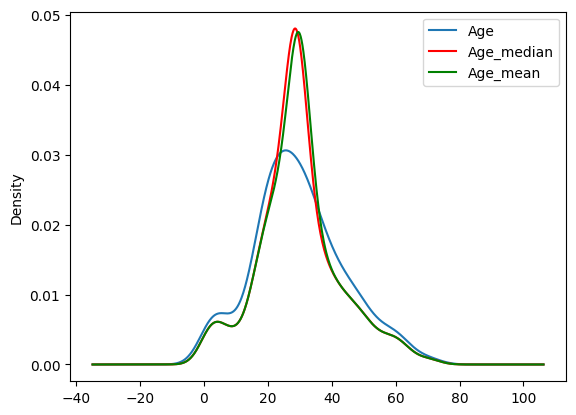

In [32]:
fig = plt.figure()
ax = fig.add_subplot(111)
# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Age_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [34]:
print("Original variance of age :",X_train['Age'].var())
print("After mean replacement variance of age :",X_train['Age_mean'].var())
print("After median replacement variance of age :",X_train['Age_median'].var())

Original variance of age : 204.34951339046142
After mean replacement variance of age : 161.81262452718676
After median replacement variance of age : 161.98956633460548


<Axes: >

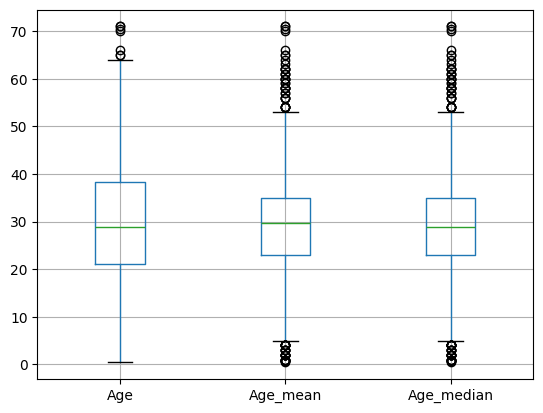

In [35]:
X_train[['Age','Age_mean','Age_median']].boxplot()

In [36]:
from sklearn.impute import SimpleImputer
imputer1 = SimpleImputer(strategy='mean')
imputer2 = SimpleImputer(strategy='median')

In [40]:
imputer1.fit_transform(X_train)

array([[ 40.        ,  27.7208    ,  40.        ,  40.        ],
       [  4.        ,  16.7       ,   4.        ,   4.        ],
       [ 47.        ,   9.        ,  47.        ,  47.        ],
       ...,
       [ 71.        ,  49.5042    ,  71.        ,  71.        ],
       [ 29.78590426, 221.7792    ,  29.78590426,  28.75      ],
       [ 29.78590426,  25.925     ,  29.78590426,  28.75      ]],
      shape=(712, 4))

In [41]:
X_train.sample(5)

,Age,Fare,Age_mean,Age_median
768,NaN,24.1500,29.785904,28.75
295,NaN,27.7208,29.785904,28.75
257,30.0,86.5000,30.000000,30.00
40,40.0,9.4750,40.000000,40.00
408,21.0,7.7750,21.000000,21.00


In [46]:
X_train['Age_constant1']=X_train['Age'].fillna(-1)
X_train['Age_constant2']=X_train['Age'].fillna(99)
X_train.sample(5)

,Age,Fare,Age_mean,Age_median,Age_constant,Age_constant1,Age_constant2
570,62.00,10.5000,62.000000,62.00,62.00,62.00,62.00
612,NaN,15.5000,29.785904,28.75,99.00,-1.00,99.00
565,24.00,24.1500,24.000000,24.00,24.00,24.00,24.00
803,0.42,8.5167,0.420000,0.42,0.42,0.42,0.42
163,17.00,8.6625,17.000000,17.00,17.00,17.00,17.00


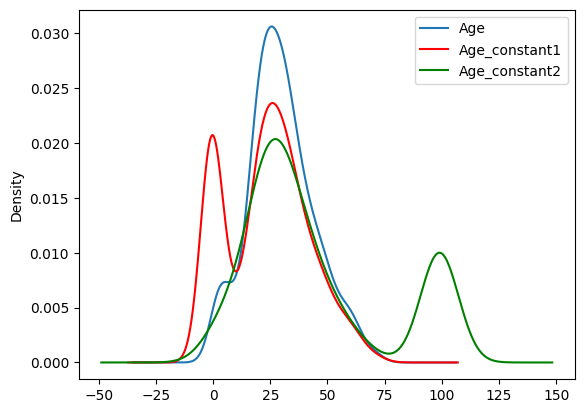

In [48]:
fig = plt.figure()
ax = fig.add_subplot(111)
# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Age_constant1'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Age_constant2'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

# Using Sklearn

In [50]:
from sklearn.compose import ColumnTransformer
trf=ColumnTransformer(transformers=[


    ('trf1',SimpleImputer(strategy='mean'),['Age']),
    ('trf2',SimpleImputer(strategy='median'),['Age'])
    ],remainder='passthrough')

In [52]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('trf1', ...), ('trf2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

In [53]:
trf.named_transformers_['trf1'].statistics_

array([29.78590426])

In [54]:
trf.named_transformers_['trf2'].statistics_

array([28.75])

In [64]:
X_train

array([[ 40.        ,  40.        ,  27.7208    , ...,  40.        ,
         40.        ,  40.        ],
       [  4.        ,   4.        ,  16.7       , ...,   4.        ,
          4.        ,   4.        ],
       [ 47.        ,  47.        ,   9.        , ...,  47.        ,
         47.        ,  47.        ],
       ...,
       [ 71.        ,  71.        ,  49.5042    , ...,  71.        ,
         71.        ,  71.        ],
       [ 29.78590426,  28.75      , 221.7792    , ...,  99.        ,
         -1.        ,  99.        ],
       [ 29.78590426,  28.75      ,  25.925     , ...,  99.        ,
         -1.        ,  99.        ]], shape=(712, 8))